In [29]:
#let's do basic imports 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [30]:
df= pd.read_csv('AmazonSalesData.csv')
df.head() # let's see the first 5 rows of the dataset


,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,5/28/2010,669165933,6/27/2010,9925,255.28,159.42,2533654.00,1582243.50,951410.50
1,Central America and the Caribbean,Grenada,Cereal,Online,C,8/22/2012,963881480,9/15/2012,2804,205.70,117.11,576782.80,328376.44,248406.36
2,Europe,Russia,Office Supplies,Offline,L,5/2/2014,341417157,5/8/2014,1779,651.21,524.96,1158502.59,933903.84,224598.75
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,6/20/2014,514321792,7/5/2014,8102,9.33,6.92,75591.66,56065.84,19525.82
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,2/1/2013,115456712,2/6/2013,5062,651.21,524.96,3296425.02,2657347.52,639077.50


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Region          100 non-null    object 
 1   Country         100 non-null    object 
 2   Item Type       100 non-null    object 
 3   Sales Channel   100 non-null    object 
 4   Order Priority  100 non-null    object 
 5   Order Date      100 non-null    object 
 6   Order ID        100 non-null    int64  
 7   Ship Date       100 non-null    object 
 8   Units Sold      100 non-null    int64  
 9   Unit Price      100 non-null    float64
 10  Unit Cost       100 non-null    float64
 11  Total Revenue   100 non-null    float64
 12  Total Cost      100 non-null    float64
 13  Total Profit    100 non-null    float64
dtypes: float64(5), int64(2), object(7)
memory usage: 11.1+ KB


In [32]:
df.describe()

,Order ID,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
count,1.000000e+02,100.000000,100.000000,100.000000,1.000000e+02,1.000000e+02,1.000000e+02
mean,5.550204e+08,5128.710000,276.761300,191.048000,1.373488e+06,9.318057e+05,4.416820e+05
std,2.606153e+08,2794.484562,235.592241,188.208181,1.460029e+06,1.083938e+06,4.385379e+05
min,1.146066e+08,124.000000,9.330000,6.920000,4.870260e+03,3.612240e+03,1.258020e+03
25%,3.389225e+08,2836.250000,81.730000,35.840000,2.687212e+05,1.688680e+05,1.214436e+05
50%,5.577086e+08,5382.500000,179.880000,107.275000,7.523144e+05,3.635664e+05,2.907680e+05
75%,7.907551e+08,7369.000000,437.200000,263.330000,2.212045e+06,1.613870e+06,6.358288e+05
max,9.940222e+08,9925.000000,668.270000,524.960000,5.997055e+06,4.509794e+06,1.719922e+06


In [33]:
#let's check for missing values
df.isnull().sum() 

Region            0
Country           0
Item Type         0
Sales Channel     0
Order Priority    0
Order Date        0
Order ID          0
Ship Date         0
Units Sold        0
Unit Price        0
Unit Cost         0
Total Revenue     0
Total Cost        0
Total Profit      0
dtype: int64

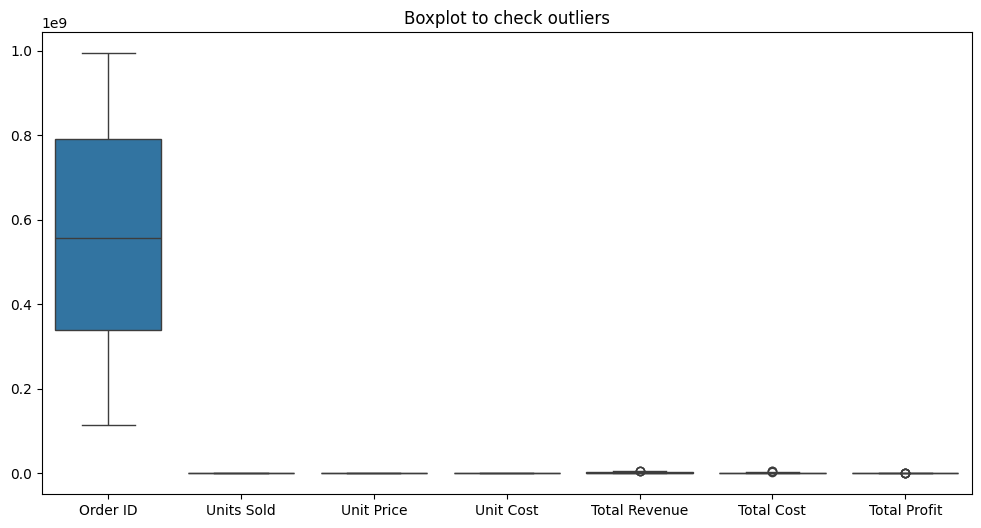

In [34]:
#let's check outliers in the dataset
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.title('Boxplot to check outliers')
plt.show()

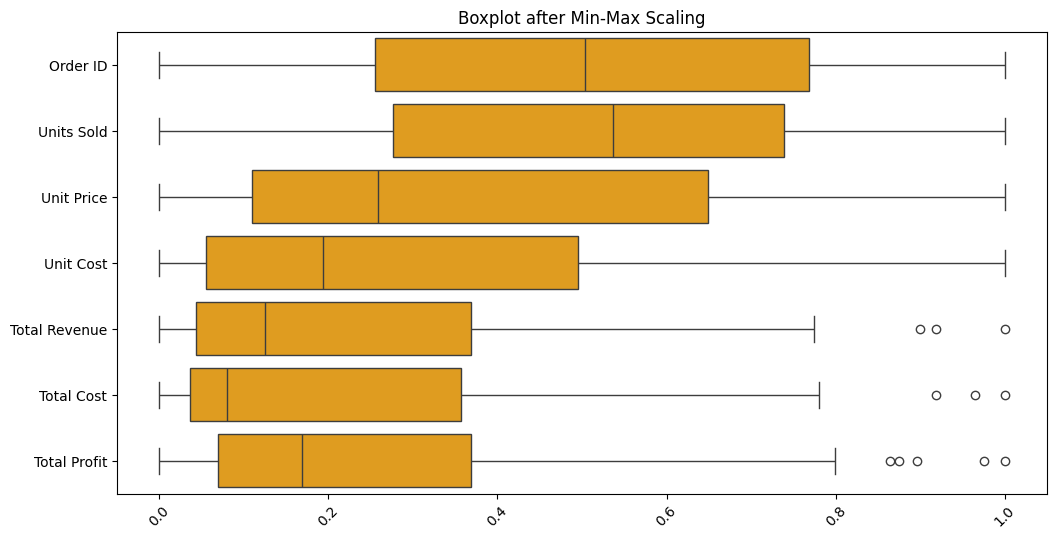

In [35]:
#let's use scaling on the numerical columns
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_scaled= pd.DataFrame(scaler.fit_transform(df.select_dtypes(include='number')), columns=df.select_dtypes(include='number').columns)
df_scaled.head()
plt.figure(figsize=(12,6))
sns.boxplot(data=df_scaled,color='orange',orient='h')
plt.xticks(rotation=45)
plt.title('Boxplot after Min-Max Scaling')
plt.show()


Boxplot analysis shows that revenue ,cost,and profit have high variability with several outliers , whereas unit pice and unit cost remain relatively stable across all orders.


In [36]:
df.columns

Index(['Region', 'Country', 'Item Type', 'Sales Channel', 'Order Priority',
       'Order Date', 'Order ID', 'Ship Date', 'Units Sold', 'Unit Price',
       'Unit Cost', 'Total Revenue', 'Total Cost', 'Total Profit'],
      dtype='object')

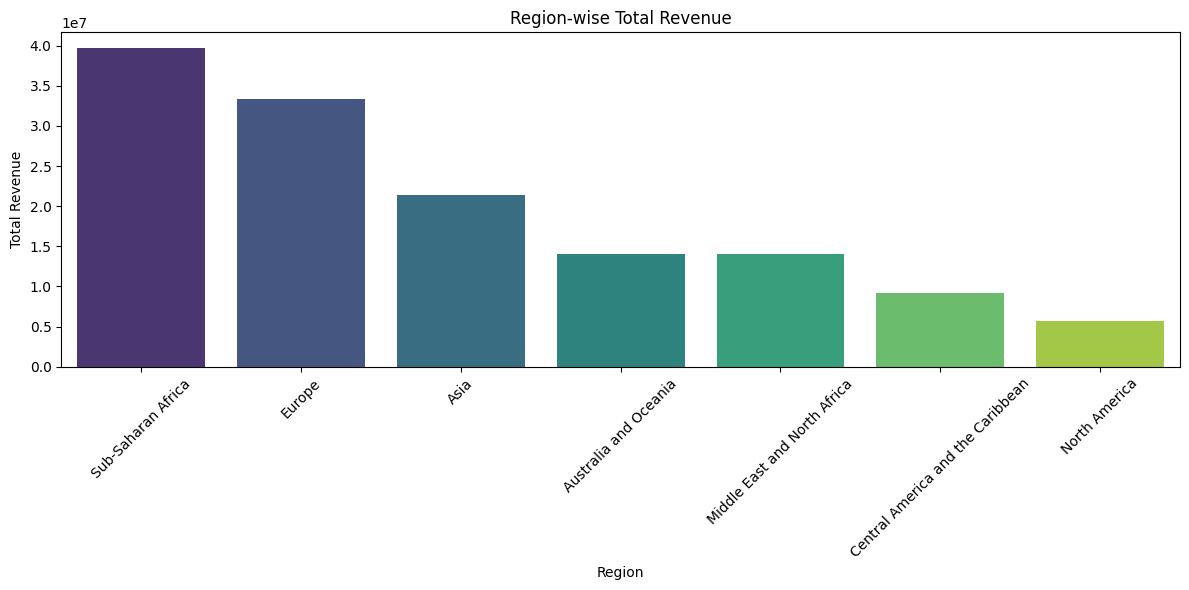

In [37]:
# Let's see region wise sales distribution (aggregate Total Revenue per region)
agg = df.groupby('Region')['Total Revenue'].sum().reset_index().sort_values('Total Revenue', ascending=False)
plt.figure(figsize=(12,6))
sns.barplot(data=agg, x='Region', y='Total Revenue', palette='viridis')
plt.title('Region-wise Total Revenue')
plt.xlabel('Region')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

So, We can see Sub-Saharan Africa generates the highest revenue and followed by Europe and Asia.

In [38]:
df

,Region,Country,Item Type,Sales Channel,Order Priority,Order Date,Order ID,Ship Date,Units Sold,Unit Price,Unit Cost,Total Revenue,Total Cost,Total Profit
0,Australia and Oceania,Tuvalu,Baby Food,Offline,H,5/28/2010,669165933,6/27/2010,9925,255.28,159.42,2533654.00,1582243.50,951410.50
1,Central America and the Caribbean,Grenada,Cereal,Online,C,8/22/2012,963881480,9/15/2012,2804,205.70,117.11,576782.80,328376.44,248406.36
2,Europe,Russia,Office Supplies,Offline,L,5/2/2014,341417157,5/8/2014,1779,651.21,524.96,1158502.59,933903.84,224598.75
3,Sub-Saharan Africa,Sao Tome and Principe,Fruits,Online,C,6/20/2014,514321792,7/5/2014,8102,9.33,6.92,75591.66,56065.84,19525.82
4,Sub-Saharan Africa,Rwanda,Office Supplies,Offline,L,2/1/2013,115456712,2/6/2013,5062,651.21,524.96,3296425.02,2657347.52,639077.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Sub-Saharan Africa,Mali,Clothes,Online,M,7/26/2011,512878119,9/3/2011,888,109.28,35.84,97040.64,31825.92,65214.72
96,Asia,Malaysia,Fruits,Offline,L,11/11/2011,810711038,12/28/2011,6267,9.33,6.92,58471.11,43367.64,15103.47
97,Sub-Saharan Africa,Sierra Leone,Vegetables,Offline,C,6/1/2016,728815257,6/29/2016,1485,154.06,90.93,228779.10,135031.05,93748.05
98,North America,Mexico,Personal Care,Offline,M,7/30/2015,559427106,8/8/2015,5767,81.73,56.67,471336.91,326815.89,144521.02


In [39]:
%pip install mysql-connector-python
import mysql.connector


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#let's upload the data to mysql database
import mysql.connector
import pandas as pd


df = pd.read_csv("AmazonSalesData.csv")

# Convert date columns to 'YYYY-MM-DD' format
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y').dt.strftime('%Y-%m-%d')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y').dt.strftime('%Y-%m-%d')

# Connect to MySQL
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Sudip@2003",
    database="amazonedb",
    port=3306
)

cursor = connection.cursor()

# Create table
cursor.execute("""
CREATE TABLE IF NOT EXISTS amazon_sales (
    Region VARCHAR(50),
    Country VARCHAR(50),
    Item_Type VARCHAR(50),
    Sales_Channel VARCHAR(20),
    Order_Priority VARCHAR(5),
    Order_Date DATE,
    Order_ID BIGINT,
    Ship_Date DATE,
    Units_Sold INT,
    Unit_Price FLOAT,
    Unit_Cost FLOAT,
    Total_Revenue FLOAT,
    Total_Cost FLOAT,
    Total_Profit FLOAT
);
""")
connection.commit()

# Insert data
insert_query = """
INSERT INTO amazon_sales (
    Region, Country, Item_Type, Sales_Channel, Order_Priority,
    Order_Date, Order_ID, Ship_Date, Units_Sold, Unit_Price,
    Unit_Cost, Total_Revenue, Total_Cost, Total_Profit
)
VALUES (
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s, %s,
    %s, %s, %s, %s
)
"""

for _, row in df.iterrows():
    cursor.execute(insert_query, tuple(row))

connection.commit()

cursor.close()
connection.close()

print("Data successfully uploaded to MySQL! 🎉")


Data successfully uploaded to MySQL! 🎉
